In [1]:
from torchvision.datasets import FashionMNIST
from typing import Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from IPython.display import HTML

## Utils

In [2]:
def unorm(x):
  return (x - x.min()) / (x.max() - x.min())

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

def plot_sample(samples, n_sample, nrows):
    # Make ncols safe (avoid 0)
    ncols = math.ceil(n_sample / nrows)

    samples = unorm(samples.cpu())

    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))

    # Ensure axes is always a 1D array
    axes = np.array(axes).reshape(-1)

    for i in range(n_sample):
        image = samples[i]

        if image.shape[0] == 1:
            image = image.squeeze(0)
            axes[i].imshow(image, cmap="gray")
        else:
            image = image.permute(1, 2, 0)
            axes[i].imshow(image)

        axes[i].axis("off")
        axes[i].set_title(f"Image {i+1}")

    # Hide any unused axes
    for j in range(n_sample, nrows * ncols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


## hyperparameters


In [4]:
# diffusion hyperparameters
timesteps = 1000
beta1 = 1e-4
beta2 = 0.02

# network hyperparameters
device = torch.device("cuda:0" if torch.cuda.is_available() else torch.device('cpu'))
n_feat = 64 # 64 hidden dimension feature
n_cfeat = 10 # context vector is of size 10 (FashionMNIST classes)
height = 32 # 32x32 image
save_dir = '/content/'

# training hyperparameters
batch_size = 100
n_epoch = 100 # Reduced for T4 quick testing if needed, or keep 40. 20 is prob fine.
lrate = 1e-3

## FashionMNIST Dataset

In [5]:
# FashionMNIST download handled by torchvision

100%|██████████| 26.4M/26.4M [01:56<00:00, 226kB/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:01<00:00, 23.4kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:05<00:00, 837kB/s] 


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 1.28MB/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



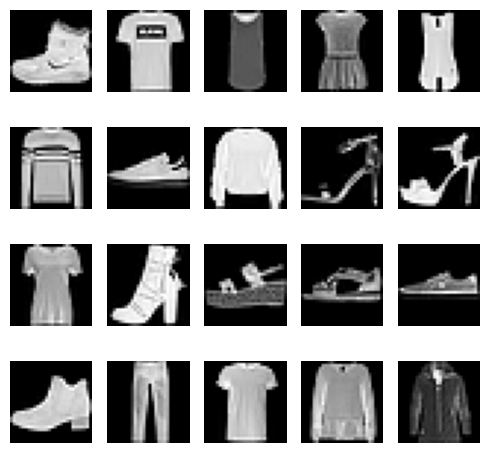

In [6]:
# Download and visualize a few FashionMNIST samples
temp_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
fig, axes = plt.subplots(4, 5, figsize=(5, 5))
axes = axes.flatten()
for i in range(20):
    img, label = temp_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [6]:
transform = transforms.Compose([
    transforms.Resize((height, height)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [7]:
train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = FashionMNIST(root='./data', train=False, download=True, transform=transform)

# For testing on a smaller subset if needed, otherwise use full
# train_dataset = torch.utils.data.Subset(train_dataset, range(1000))


In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## UNet

So what model do we use to do this magical 'denoising' step? We've looked a little at basic convolutional neural networks that take in an image and output something like a classification. And we've seen autoencoders that go from an image down to a latent representation and back to an output image. Perhaps one of these would be suitable?

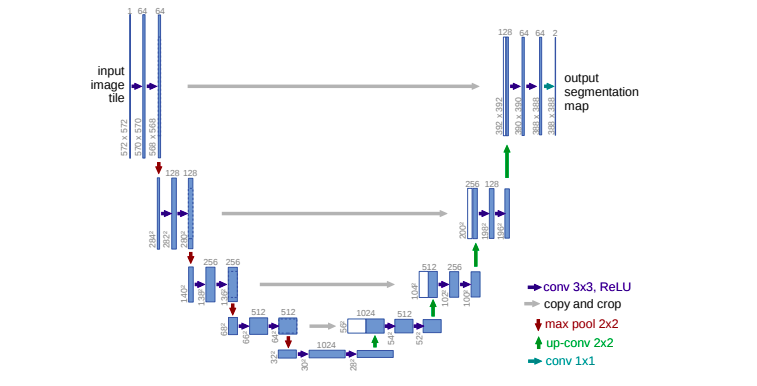

(Unet diagram from [the 2015 paper](https://arxiv.org/abs/1505.04597))

One issue with a typical 'bottlekneck' architecture like an autoencoder is that by design they loose the details around exact pixel coordinates. To get around this, an architecture called the Unet was introduced. Originally designed for segmentation tasks, the architecture (shown above) passes information from high-resolution, early layers to later layers. These 'shortcuts' let the network use detailed features from the original image while also capturing more high-level semantic information from the deeper layers.

These networks turned out to be great at all sorts of image-to-image tasks. Colorization , segmentation and so on. These days, typical unet models incorporate ideas such as attention and can be built around pretrained 'backbones' like resnet-50 for transfer learning tasks.

The implementation below is a fairly typical modern Unet with one extra trick: a TimeEmbedding which encodes the time step (t) and lets the model use this as conditioning information by passing it in in the middle of the network. Take a peek at the code and see if you can figure out roughly what's going on in the forward pass.



In [9]:
class ResidualConvBlock(nn.Module):
    def __init__(
        self, in_channels: int, out_channels: int, is_res: bool = False
    ) -> None:
        super().__init__()

        # Check if input and output channels are the same for the residual connection
        self.same_channels = in_channels == out_channels

        # Flag for whether or not to use residual connection
        self.is_res = is_res

        # First convolutional layer
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),   # 3x3 kernel with stride 1 and padding 1
            nn.BatchNorm2d(out_channels),   # Batch normalization
            nn.GELU(),   # GELU activation function
        )

        # Second convolutional layer
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),   # 3x3 kernel with stride 1 and padding 1
            nn.BatchNorm2d(out_channels),   # Batch normalization
            nn.GELU(),   # GELU activation function
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # If using residual connection
        if self.is_res:
            # Apply first convolutional layer
            x1 = self.conv1(x)

            # Apply second convolutional layer
            x2 = self.conv2(x1)

            # If input and output channels are the same, add residual connection directly
            if self.same_channels:
                out = x + x2
            else:
                # If not, apply a 1x1 convolutional layer to match dimensions before adding residual connection
                shortcut = nn.Conv2d(x.shape[1], x2.shape[1], kernel_size=1, stride=1, padding=0).to(x.device)
                out = shortcut(x) + x2
            #print(f"resconv forward: x {x.shape}, x1 {x1.shape}, x2 {x2.shape}, out {out.shape}")

            # Normalize output tensor
            return out / 1.414

        # If not using residual connection, return output of second convolutional layer
        else:
            x1 = self.conv1(x)
            x2 = self.conv2(x1)
            return x2

    # Method to get the number of output channels for this block
    def get_out_channels(self):
        return self.conv2[0].out_channels

    # Method to set the number of output channels for this block
    def set_out_channels(self, out_channels):
        self.conv1[0].out_channels = out_channels
        self.conv2[0].in_channels = out_channels
        self.conv2[0].out_channels = out_channels



class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetUp, self).__init__()

        # Create a list of layers for the upsampling block
        # The block consists of a ConvTranspose2d layer for upsampling, followed by two ResidualConvBlock layers
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 2, 2),
            ResidualConvBlock(out_channels, out_channels),
            ResidualConvBlock(out_channels, out_channels),
        ]

        # Use the layers to create a sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        # Concatenate the input tensor x with the skip connection tensor along the channel dimension
        x = torch.cat((x, skip), 1)

        # Pass the concatenated tensor through the sequential model and return the output
        x = self.model(x)
        return x


class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetDown, self).__init__()

        # Create a list of layers for the downsampling block
        # Each block consists of two ResidualConvBlock layers, followed by a MaxPool2d layer for downsampling
        layers = [ResidualConvBlock(in_channels, out_channels), ResidualConvBlock(out_channels, out_channels), nn.MaxPool2d(2)]

        # Use the layers to create a sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # Pass the input through the sequential model and return the output
        return self.model(x)

class EmbedFC(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedFC, self).__init__()
        '''
        This class defines a generic one layer feed-forward neural network for embedding input data of
        dimensionality input_dim to an embedding space of dimensionality emb_dim.
        '''
        self.input_dim = input_dim

        # define the layers for the network
        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
        ]

        # create a PyTorch sequential model consisting of the defined layers
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # flatten the input tensor
        x = x.view(-1, self.input_dim)
        # apply the model layers to the flattened tensor
        return self.model(x)

In [10]:
class Unet(nn.Module):
    def __init__(self, in_channels, n_feat=256, n_cfeat=10, height=28, n_T=1000):  # cfeat - context features
        super(Unet, self).__init__()

        # number of input channels, number of intermediate feature maps and number of classes
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_cfeat = n_cfeat
        self.h = height  #assume h == w. must be divisible by 4, so 28,24,20,16...
        self.n_T = n_T

        # Initialize the initial convolutional layer
        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        # Initialize the down-sampling path of the U-Net with two levels
        self.down1 = UnetDown(n_feat, n_feat)        # down1 #[10, 256, 8, 8]
        self.down2 = UnetDown(n_feat, 2 * n_feat)    # down2 #[10, 256, 4,  4]

         # original: self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
        self.to_vec = nn.Sequential(nn.AvgPool2d((4)), nn.GELU())

        # Embed the timestep and context labels with a one-layer fully connected neural network
        self.timeembed1 = EmbedFC(1, 2*n_feat)
        self.timeembed2 = EmbedFC(1, 1*n_feat)
        self.contextembed1 = EmbedFC(n_cfeat, 2*n_feat)
        self.contextembed2 = EmbedFC(n_cfeat, 1*n_feat)

        # Initialize the up-sampling path of the U-Net with three levels
        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, self.h//8, self.h//8), # up-sample
            nn.GroupNorm(8, 2 * n_feat), # normalize
            nn.ReLU(),
        )
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)

        # Initialize the final convolutional layers to map to the same number of channels as the input image
        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1), # reduce number of feature maps   #in_channels, out_channels, kernel_size, stride=1, padding=0
            nn.GroupNorm(8, n_feat), # normalize
            nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1), # map to same number of channels as input
        )

    
    def forward(self, x, t, c=None):
        # Ensure float timestep for embedding
        t = t.float()
        # If you know timesteps, prefer t = t / timesteps outside; otherwise keep t in [0,1] already
        # (best: pass t already normalized from training loop)
    
        x0 = self.init_conv(x)
        down1 = self.down1(x0)
        down2 = self.down2(down1)
    
        hiddenvec = self.to_vec(down2)
    
        if c is None:
            c = torch.zeros(x0.shape[0], self.n_cfeat, device=x0.device, dtype=x0.dtype)
    
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)
    
        up1 = self.up0(hiddenvec)                          # should now be same spatial size as down2
        up2 = self.up1(cemb1 * up1 + temb1, down2)         # keep original skip (channels match!)
        up3 = self.up2(cemb2 * up2 + temb2, down1)
        out = self.out(torch.cat((up3, x0), 1))

        return out
    
    

In [11]:
def forward(self, x, t, c=None):
        """
        x : (batch, in_channels, h, w)  input image
        t : (batch,) or (batch, 1)      timestep
        c : (batch, n_cfeat) or None    context label (one-hot or embedding)
        """
        import torch.nn.functional as F

        # Ensure float dtype for time embedding MLPs
        t = t.float()

        # Normalize t if n_T exists; otherwise keep as float
        if hasattr(self, "n_T") and self.n_T is not None:
            t = t / self.n_T

        # Initial conv
        x0 = self.init_conv(x)  # keep a named variable for clarity

        # Down path
        down1 = self.down1(x0)      # e.g. (B, 2*n_feat, 8, 8)
        down2 = self.down2(down1)   # e.g. (B, 2*n_feat, 4, 4)

        # Bottleneck vector
        hiddenvec = self.to_vec(down2)

        # Default context (unconditional)
        if c is None:
            c = torch.zeros(x.shape[0], self.n_cfeat, device=x.device, dtype=x.dtype)

        # Context + time embeddings
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)

        # Up path
        up1 = self.up0(hiddenvec)

        skip1 = down2
        if up1.shape[-2:] != skip1.shape[-2:]:
            skip1 = F.interpolate(skip1, size=up1.shape[-2:], mode="nearest")

        up2 = self.up1(cemb1 * up1 + temb1, skip1)

        skip2 = down1
        if up2.shape[-2:] != skip2.shape[-2:]:
            skip2 = F.interpolate(skip2, size=up2.shape[-2:], mode="nearest")

        up3 = self.up2(cemb2 * up2 + temb2, skip2)

        # Final skip with x0 (same resolution as output)
        if up3.shape[-2:] != x0.shape[-2:]:
            x0_resized = F.interpolate(x0, size=up3.shape[-2:], mode="nearest")
        else:
            x0_resized = x0

        out = self.out(torch.cat((up3, x0_resized), 1))

        if out.shape[-2:] != x.shape[-2:]:
            out = F.interpolate(out, size=x.shape[-2:], mode="nearest")

        return out


## Training

In [12]:
# construct model
nn_model = Unet(in_channels=1, n_feat=n_feat, n_cfeat=n_cfeat, height=height, n_T=timesteps).to(device)

In [13]:
#construct optimizer
optim = torch.optim.Adam(nn_model.parameters(), lr=lrate)

We want to set up a "**variance schedule**" β, where $\beta_t$ specifies how much noise we want to add at that step. You get fancy schedules but we'll stick with a linear one for now. \\
At each time step t, the variance of the noise added to the previous step is predetermined by the variance schedule, and it's marked as $\beta_t$, where 0 < $\beta_1$ < $\beta_t$ < $\beta_2$ < 1.

In [14]:
# Create Linear Scheduler - beta1 and beta2 are given in the hyperparameters block
# We precompute useful constants for the forward and reverse diffusion processes.

# betas: (T,)
b_t = torch.linspace(beta1, beta2, timesteps, device=device)

# alphas and cumulative products
a_t = 1.0 - b_t
ab_t = torch.cumprod(a_t, dim=0)                 # alpha_bar_t
sqrt_ab_t = torch.sqrt(ab_t)
sqrt_one_minus_ab_t = torch.sqrt(1.0 - ab_t)

# A small helper to gather per-timestep scalars for a batch and reshape for broadcasting
def extract(v, t, x_shape):
    t = t.long()
    out = v.gather(0, t)
    return out.view((t.shape[0],) + (1,) * (len(x_shape) - 1))


# posterior variance used in DDPM sampling (q(x_{t-1} | x_t, x_0))
ab_t_prev = torch.cat([torch.tensor([1.0], device=device), ab_t[:-1]], dim=0)
posterior_var = b_t * (1.0 - ab_t_prev) / (1.0 - ab_t)
posterior_log_var_clipped = torch.log(torch.clamp(posterior_var, min=1e-20))


### Forward

Now, we want to train our model at different time steps and we don't particulary want to iterativly add little bits of noise a bunch of times just to train one sample.

Luckily, some smart people did some fancy maths (link https://lilianweng.github.io/posts/2018-08-12-vae/#reparameterization-trick) using something called the reparameterization trick that lets us get $x_t$ for any t given $x_0$.

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1 - \bar{\alpha}_t)\mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$


In [15]:
# helper function: perturbs an image to a specified noise level

def perturb_input(x0: torch.Tensor, t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """Sample x_t from q(x_t | x_0) at arbitrary timestep(s) t.

    Args:
        x0: clean images, shape [B,C,H,W]
        t: timesteps, shape [B] (values in [0, T-1])

    Returns:
        x_t: noised images at timestep t
        eps: the Gaussian noise used to create x_t
    """
    eps = torch.randn_like(x0)
    sqrt_ab = extract(sqrt_ab_t, t, x0.shape)
    sqrt_omab = extract(sqrt_one_minus_ab_t, t, x0.shape)
    x_t = sqrt_ab * x0 + sqrt_omab * eps
    return x_t, eps


In [16]:
torch.backends.cudnn.benchmark = True

### Train Diffsion

Now that we have our 'diffusion model' defined, we need to train it to predict the noise given $x_t$ and $t$.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11120\214857487.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # create ONCE


epoch 0


  0%|          | 0/600 [00:00<?, ?it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_11120\214857487.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
loss: 0.0493: 100%|██████████| 600/600 [00:45<00:00, 13.32it/s]


epoch 0 mean loss: 0.1009
epoch 1


loss: 0.0486: 100%|██████████| 600/600 [00:44<00:00, 13.52it/s]


...

epoch 2 mean loss: 0.0412
epoch 3


loss: 0.0233: 100%|██████████| 600/600 [00:45<00:00, 13.21it/s]


epoch 3 mean loss: 0.0379
epoch 4


loss: 0.0433: 100%|██████████| 600/600 [00:45<00:00, 13.20it/s]


epoch 4 mean loss: 0.0348
Saved checkpoint: checkpoints\unet_epoch_0005.pt


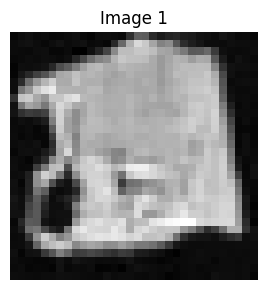

epoch 5


loss: 0.0320: 100%|██████████| 600/600 [00:45<00:00, 13.31it/s]


epoch 5 mean loss: 0.0338
epoch 6


loss: 0.0509: 100%|██████████| 600/600 [00:45<00:00, 13.22it/s]


epoch 6 mean loss: 0.0323
epoch 7


...

epoch 7 mean loss: 0.0322
epoch 8


loss: 0.0391: 100%|██████████| 600/600 [00:45<00:00, 13.15it/s]


epoch 8 mean loss: 0.0310
epoch 9


loss: 0.0351: 100%|██████████| 600/600 [00:45<00:00, 13.20it/s]


epoch 9 mean loss: 0.0308
Saved checkpoint: checkpoints\unet_epoch_0010.pt


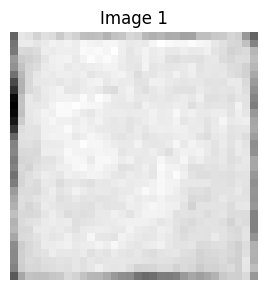

epoch 10


loss: 0.0380: 100%|██████████| 600/600 [00:45<00:00, 13.25it/s]


epoch 10 mean loss: 0.0305
epoch 11


loss: 0.0370: 100%|██████████| 600/600 [00:45<00:00, 13.16it/s]


epoch 11 mean loss: 0.0300
epoch 12


...

epoch 12 mean loss: 0.0299
epoch 13


loss: 0.0453: 100%|██████████| 600/600 [00:45<00:00, 13.15it/s]


epoch 13 mean loss: 0.0295
epoch 14


loss: 0.0218: 100%|██████████| 600/600 [00:45<00:00, 13.16it/s]


epoch 14 mean loss: 0.0288
Saved checkpoint: checkpoints\unet_epoch_0015.pt


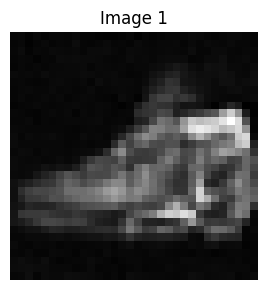

epoch 15


loss: 0.0273: 100%|██████████| 600/600 [00:45<00:00, 13.21it/s]


epoch 15 mean loss: 0.0283
epoch 16


loss: 0.0322: 100%|██████████| 600/600 [00:45<00:00, 13.16it/s]


epoch 16 mean loss: 0.0283
epoch 17


...

epoch 17 mean loss: 0.0278
epoch 18


loss: 0.0286: 100%|██████████| 600/600 [00:45<00:00, 13.15it/s]


epoch 18 mean loss: 0.0279
epoch 19


loss: 0.0358: 100%|██████████| 600/600 [00:45<00:00, 13.14it/s]


epoch 19 mean loss: 0.0277
Saved checkpoint: checkpoints\unet_epoch_0020.pt


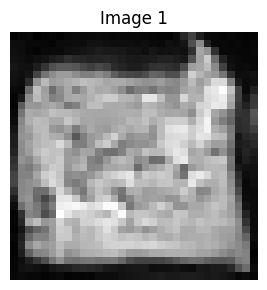

epoch 20


loss: 0.0289: 100%|██████████| 600/600 [00:45<00:00, 13.28it/s]


epoch 20 mean loss: 0.0277
epoch 21


loss: 0.0265: 100%|██████████| 600/600 [00:46<00:00, 12.89it/s]


epoch 21 mean loss: 0.0275
epoch 22


...

epoch 22 mean loss: 0.0269
epoch 23


loss: 0.0210: 100%|██████████| 600/600 [00:46<00:00, 12.85it/s]


epoch 23 mean loss: 0.0267
epoch 24


loss: 0.0298: 100%|██████████| 600/600 [00:45<00:00, 13.06it/s]


epoch 24 mean loss: 0.0272
Saved checkpoint: checkpoints\unet_epoch_0025.pt


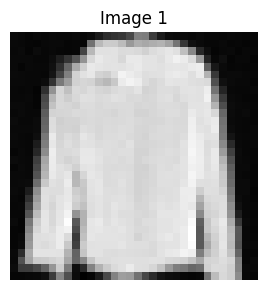

epoch 25


loss: 0.0260: 100%|██████████| 600/600 [00:46<00:00, 12.97it/s]


epoch 25 mean loss: 0.0260
epoch 26


loss: 0.0280: 100%|██████████| 600/600 [00:46<00:00, 12.85it/s]


epoch 26 mean loss: 0.0265
epoch 27


...

epoch 27 mean loss: 0.0264
epoch 28


loss: 0.0273: 100%|██████████| 600/600 [00:48<00:00, 12.48it/s]


epoch 28 mean loss: 0.0265
epoch 29


loss: 0.0271: 100%|██████████| 600/600 [00:47<00:00, 12.64it/s]


epoch 29 mean loss: 0.0266
Saved checkpoint: checkpoints\unet_epoch_0030.pt


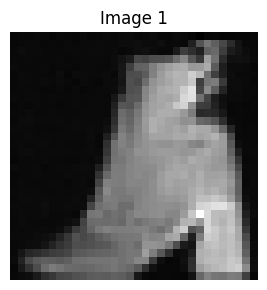

In [68]:
import os

# ---- config ----
save_every = 5
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

# Train Model (unconditional)
nn_model.train()
mse = nn.MSELoss()

scaler = torch.cuda.amp.GradScaler()  # create ONCE

losses_step = []   # store every iteration loss
losses_epoch = []  # store mean loss per epoch

for ep in range(n_epoch):
    print(f"epoch {ep}")
    pbar = tqdm(train_dataloader)

    running = 0.0
    n_steps = 0

    for x, _ in pbar:
        x = x.to(device, non_blocking=True)

        # t_long for indexing schedules, t for model time-embedding
        t_long = torch.randint(0, timesteps, (x.size(0),), device=device)
        t = t_long.float() / timesteps

        with torch.cuda.amp.autocast():
            x_t, eps = perturb_input(x, t_long)   # ONLY ONCE
            eps_pred = nn_model(x_t, t)           # model gets float t
            loss = mse(eps_pred, eps)

        optim.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()

        # bookkeeping
        loss_val = float(loss.item())
        losses_step.append(loss_val)

        running += loss_val
        n_steps += 1

        pbar.set_description(f"loss: {loss_val:.4f}")

    epoch_mean = running / max(n_steps, 1)
    losses_epoch.append(epoch_mean)
    print(f"epoch {ep} mean loss: {epoch_mean:.4f}")

    # ---- checkpoint every 5 epochs (and also at the very end) ----
    is_ckpt_epoch = ((ep + 1) % save_every == 0) or (ep == n_epoch - 1)
    if is_ckpt_epoch:
        ckpt_path = os.path.join(ckpt_dir, f"unet_epoch_{ep+1:04d}.pt")
        torch.save(
            {
                "epoch": ep,  # last finished epoch index
                "model_state_dict": nn_model.state_dict(),
                "optim_state_dict": optim.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "losses_step": losses_step,
                "losses_epoch": losses_epoch,
                "timesteps": timesteps,
                # Optional: RNG states (helps reproducibility on resume)
                "rng_state_torch": torch.get_rng_state(),
                "rng_state_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            },
            ckpt_path,
        )
        
        print(f"Saved checkpoint: {ckpt_path}")

        nn_model.eval()
        sample = sample_ddpm(1)         # returns a tensor (1, C, H, W)
        plot_sample(sample, 1, 1)       # shows it
        nn_model.train()



In [17]:
import torch
scaler = torch.cuda.amp.GradScaler()  # create ONCE

ckpt = torch.load("checkpoints/unet_epoch_0080.pt", map_location=device)

nn_model.load_state_dict(ckpt["model_state_dict"])
optim.load_state_dict(ckpt["optim_state_dict"])
scaler.load_state_dict(ckpt["scaler_state_dict"])

losses_step = ckpt.get("losses_step", [])
losses_epoch = ckpt.get("losses_epoch", [])

start_epoch = ckpt["epoch"] + 1  # resume from next epoch

# ---- Optional RNG restore (safe) ----
rng = ckpt.get("rng_state_torch", None)
if rng is not None:
    try:
        if not isinstance(rng, torch.Tensor):
            rng = torch.tensor(rng, dtype=torch.uint8)
        else:
            rng = rng.to(dtype=torch.uint8, device="cpu")
        torch.set_rng_state(rng)
    except Exception as e:
        print("Warning: could not restore CPU RNG state:", e)

cuda_rng = ckpt.get("rng_state_cuda", None)
if torch.cuda.is_available() and cuda_rng is not None:
    try:
        fixed = []
        for s in cuda_rng:
            if not isinstance(s, torch.Tensor):
                s = torch.tensor(s, dtype=torch.uint8)
            else:
                s = s.to(dtype=torch.uint8, device=device)
            fixed.append(s)
        torch.cuda.set_rng_state_all(fixed)
    except Exception as e:
        print("Warning: could not restore CUDA RNG state:", e)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20144\2447289931.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # create ONCE
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20144\2447289931.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start

In [18]:
import copy

ema_decay = 0.999
ema_model = copy.deepcopy(nn_model).eval()
for p in ema_model.parameters():
    p.requires_grad_(False)

@torch.no_grad()
def ema_update(ema_model, model, decay):
    msd = model.state_dict()
    esd = ema_model.state_dict()
    for k in esd.keys():
        if esd[k].dtype.is_floating_point:
            esd[k].mul_(decay).add_(msd[k], alpha=1.0 - decay)
        else:
            esd[k].copy_(msd[k])


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18220\2263800934.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


epoch 60


  0%|          | 0/600 [00:00<?, ?it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_18220\2263800934.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
loss: 0.0251: 100%|██████████| 600/600 [00:50<00:00, 11.77it/s]


epoch 60 mean loss: 0.0243
epoch 61


loss: 0.0364: 100%|██████████| 600/600 [00:48<00:00, 12.46it/s]


...

epoch 62 mean loss: 0.0246
epoch 63


loss: 0.0212: 100%|██████████| 600/600 [00:47<00:00, 12.53it/s]


epoch 63 mean loss: 0.0243
epoch 64


loss: 0.0232: 100%|██████████| 600/600 [00:48<00:00, 12.43it/s]


epoch 64 mean loss: 0.0245
Saved checkpoint: checkpoints\unet_epoch_0065.pt


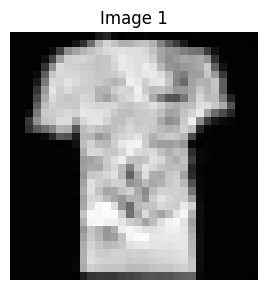

epoch 65


loss: 0.0208: 100%|██████████| 600/600 [00:48<00:00, 12.48it/s]


epoch 65 mean loss: 0.0243
epoch 66


loss: 0.0359: 100%|██████████| 600/600 [00:49<00:00, 12.19it/s]


epoch 66 mean loss: 0.0240
epoch 67


...

epoch 67 mean loss: 0.0244
epoch 68


loss: 0.0251: 100%|██████████| 600/600 [00:49<00:00, 12.14it/s]


epoch 68 mean loss: 0.0242
epoch 69


loss: 0.0225: 100%|██████████| 600/600 [00:49<00:00, 12.24it/s]


epoch 69 mean loss: 0.0242
Saved checkpoint: checkpoints\unet_epoch_0070.pt


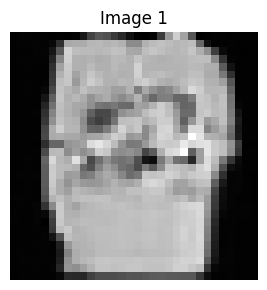

epoch 70


loss: 0.0316: 100%|██████████| 600/600 [00:48<00:00, 12.31it/s]


epoch 70 mean loss: 0.0246
epoch 71


loss: 0.0280: 100%|██████████| 600/600 [00:49<00:00, 12.24it/s]


epoch 71 mean loss: 0.0239
epoch 72


...

epoch 72 mean loss: 0.0242
epoch 73


loss: 0.0263: 100%|██████████| 600/600 [00:49<00:00, 12.24it/s]


epoch 73 mean loss: 0.0242
epoch 74


loss: 0.0142: 100%|██████████| 600/600 [00:48<00:00, 12.25it/s]


epoch 74 mean loss: 0.0243
Saved checkpoint: checkpoints\unet_epoch_0075.pt


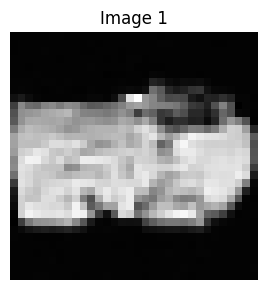

epoch 75


loss: 0.0314: 100%|██████████| 600/600 [00:48<00:00, 12.41it/s]


epoch 75 mean loss: 0.0242
epoch 76


loss: 0.0236: 100%|██████████| 600/600 [00:48<00:00, 12.32it/s]


epoch 76 mean loss: 0.0238
epoch 77


...

epoch 77 mean loss: 0.0241
epoch 78


loss: 0.0249: 100%|██████████| 600/600 [00:48<00:00, 12.33it/s]


epoch 78 mean loss: 0.0241
epoch 79


loss: 0.0220: 100%|██████████| 600/600 [05:25<00:00,  1.85it/s]  


epoch 79 mean loss: 0.0241
Saved checkpoint: checkpoints\unet_epoch_0080.pt


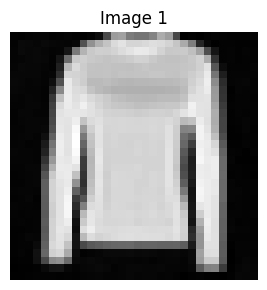

epoch 80


loss: 0.0284:   5%|▌         | 30/600 [00:05<01:42,  5.55it/s]


KeyboardInterrupt: 

In [50]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm

# ---- config ----
save_every = 5
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

nn_model.train()
mse = nn.MSELoss()

# Use new AMP API to avoid FutureWarning
scaler = torch.cuda.amp.GradScaler()

# IMPORTANT:
# Assume these already exist from checkpoint loading:
# start_epoch, losses_step, losses_epoch
# If not, uncomment defaults:
# start_epoch = 0
# losses_step, losses_epoch = [], []

for ep in range(start_epoch, n_epoch):
    print(f"epoch {ep}")
    pbar = tqdm(train_dataloader)

    running = 0.0
    n_steps = 0

    for x, _ in pbar:
        x = x.to(device, non_blocking=True)

        # t_long for schedule indexing, t for model embedding
        t_long = torch.randint(0, timesteps, (x.size(0),), device=device)
        t = t_long.float() / timesteps

        with torch.cuda.amp.autocast():
            x_t, eps = perturb_input(x, t_long)
            eps_pred = nn_model(x_t, t)
            loss = mse(eps_pred, eps)

        optim.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        ema_update(ema_model, nn_model, ema_decay)


        loss_val = float(loss.item())
        losses_step.append(loss_val)

        running += loss_val
        n_steps += 1
        pbar.set_description(f"loss: {loss_val:.4f}")

    epoch_mean = running / max(n_steps, 1)
    losses_epoch.append(epoch_mean)
    print(f"epoch {ep} mean loss: {epoch_mean:.4f}")

    # ---- checkpoint + sample every 5 epochs (and also at the very end) ----
    is_ckpt_epoch = ((ep + 1) % save_every == 0) or (ep == n_epoch - 1)

    if is_ckpt_epoch:
        # 1) Save checkpoint
        ckpt_path = os.path.join(ckpt_dir, f"unet_epoch_{ep+1:04d}.pt")
        torch.save(
            {
                "epoch": ep,  # last finished epoch index
                "model_state_dict": nn_model.state_dict(),
                "optim_state_dict": optim.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "losses_step": losses_step,
                "losses_epoch": losses_epoch,
                "timesteps": timesteps,
                "rng_state_torch": torch.get_rng_state().cpu(),
                "rng_state_cuda": [s.cpu() for s in torch.cuda.get_rng_state_all()] if torch.cuda.is_available() else None,
            },
            ckpt_path,
        )
        print(f"Saved checkpoint: {ckpt_path}")

        # 2) Print / show 1 sample
        nn_model.eval()
        sample = sample_ddpm(1)         # returns a tensor (1, C, H, W)
        plot_sample(sample, 1, 1)       # shows it
        nn_model.train()


## DDPM Sampling

Now we need to define the reverse step $p_\theta(\mathbf{x}_{t-1} \vert \mathbf{x}_t)$

See that little $_\theta$? That often indicates 'learned parameters' - in this case our unet model! We use our model to predict the noise and then 'undo' the forward noise steps one at a time to go from an image that is pure noise to one that looks like a real image. \\
Below image show the sampling algorithm

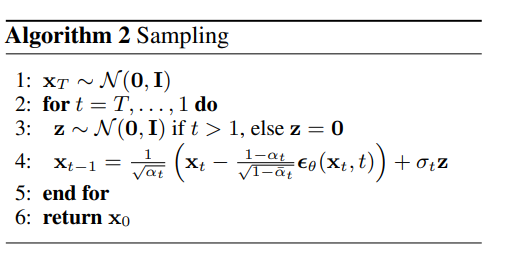

In [19]:
@torch.no_grad()
def sample_ddpm(n_sample: int):
    ema_model.eval()
    x = torch.randn(n_sample, 1, height, height, device=device)

    for t_ in reversed(range(timesteps)):
        t_long = torch.full((n_sample,), t_, device=device, dtype=torch.long)
        t = (t_long.float() / timesteps).unsqueeze(1)  # (B,1)

        eps = ema_model(x, t)

        beta  = extract(b_t,  t_long, x.shape)
        alpha = extract(a_t,  t_long, x.shape)
        ab    = extract(ab_t, t_long, x.shape)

        # x0 prediction + clip
        x0_hat = (x - torch.sqrt(1.0 - ab) * eps) / torch.sqrt(ab)
        x0_hat = x0_hat.clamp(-1.0, 1.0)

        # mean using clipped x0_hat (DDPM posterior mean in x0-param form)
        mean = (1.0 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1.0 - ab)) * eps)

        if t_ == 0:
            x = mean
        else:
            var = extract(posterior_var, t_long, x.shape)
            var = torch.clamp(var, min=1e-20)
            x = mean + torch.sqrt(var) * torch.randn_like(x)

    return x


## DDIM Sampling

In [20]:
@torch.no_grad()
def sample_ddim(n_sample: int, n_steps: int = 20):
    nn_model.eval()

    x = torch.randn(n_sample, 1, height, height, device=device)

    step_size = timesteps // n_steps
    t_seq = list(range(timesteps - 1, -1, -step_size))
    if t_seq[-1] != 0:
        t_seq.append(0)

    for i in range(len(t_seq) - 1):
        t_cur = t_seq[i]
        t_next = t_seq[i + 1]

        t_long = torch.full((n_sample,), t_cur, device=device, dtype=torch.long)
        t = (t_long.float() / timesteps).unsqueeze(1)   # (B,1) float, matches training

        eps_theta = nn_model(x, t)

        alpha_bar_cur  = extract(ab_t, torch.full((n_sample,), t_cur,  device=device, dtype=torch.long), x.shape)
        alpha_bar_next = extract(ab_t, torch.full((n_sample,), t_next, device=device, dtype=torch.long), x.shape)

        # x0 prediction
        x0_hat = (x - torch.sqrt(1.0 - alpha_bar_cur) * eps_theta) / torch.sqrt(alpha_bar_cur)

        # DDIM deterministic update (eta=0)
        x = torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1.0 - alpha_bar_next) * eps_theta

    return x


## Results

In [68]:
samples = sample_ddpm(50)

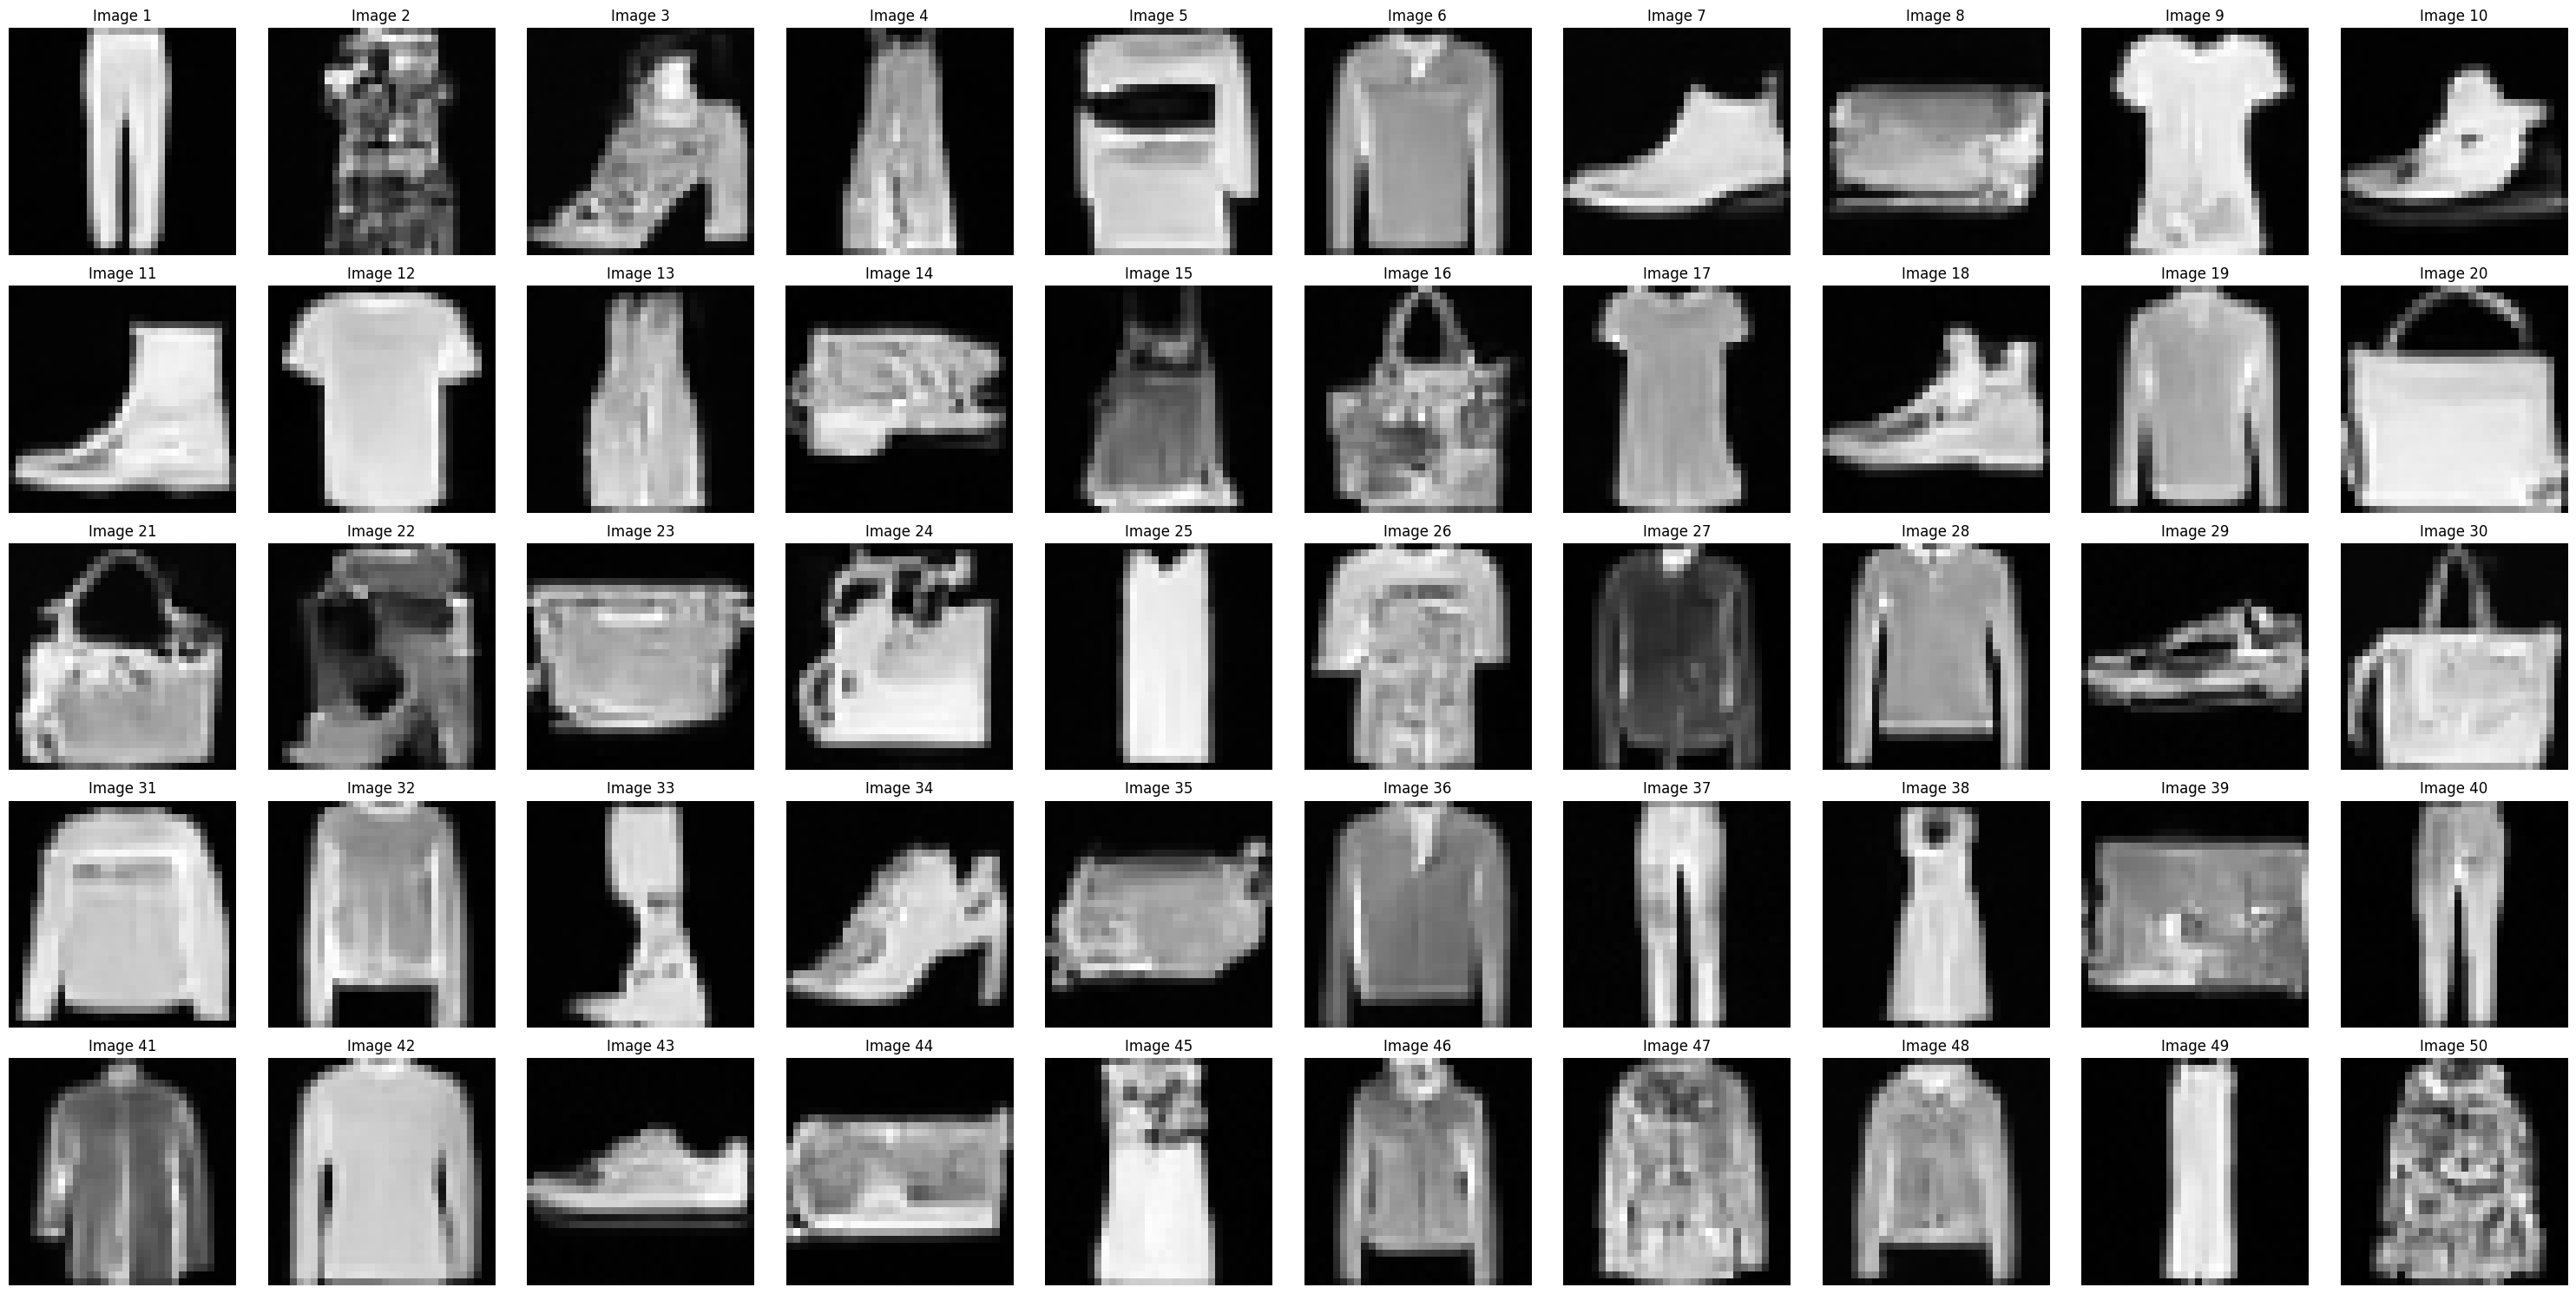

In [69]:
plot_sample(samples, 50, 5)

In [70]:
samples = sample_ddim(50, 100)

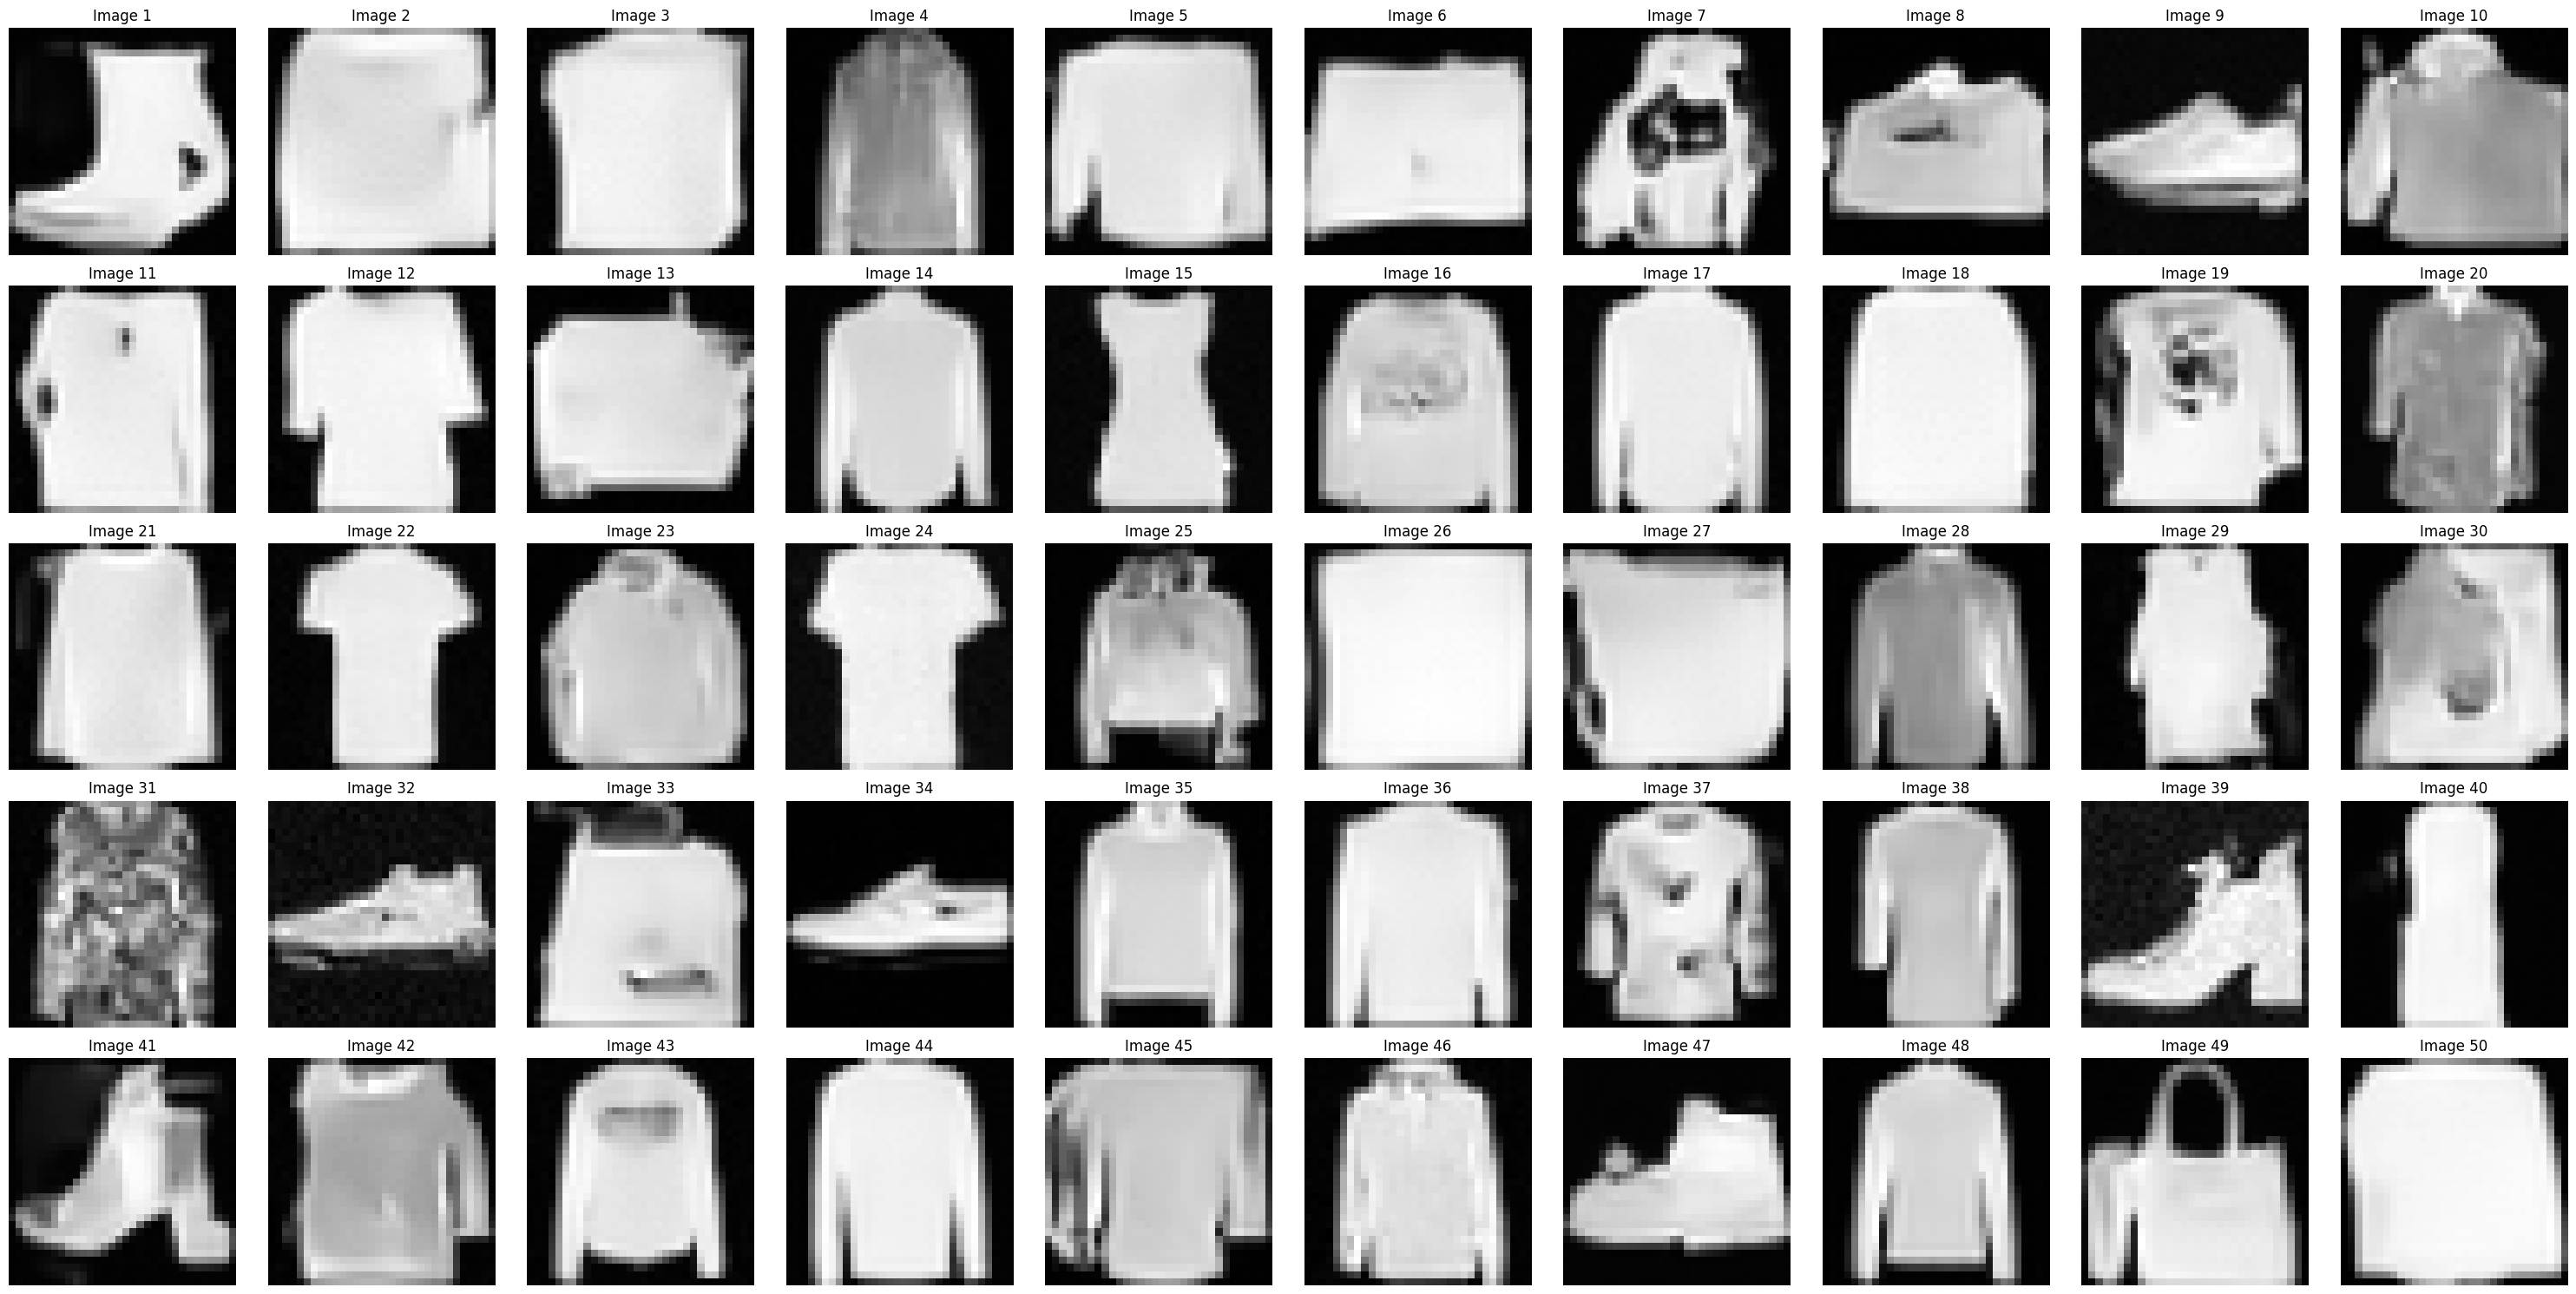

In [71]:
plot_sample(samples, 50, 5)

# Compare DDIM and DDPM Time

In [87]:
%timeit -r 1 sample_ddim(50, 80)
%timeit -r 1 sample_ddpm(50)

1.4 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
16.8 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


# Evaluating the Generated Samples:

Now we want to evaluate our model. For this, we use the FID score.

First, read this link to become familiar with this metric and its usage in your code.

In [21]:
from torchmetrics.image.fid import FrechetInceptionDistance
import torch
from tqdm import tqdm

nn_model.eval()

@torch.no_grad()
def to_uint8_3ch(x):
    # x: [-1,1] float tensor [B,1,H,W] (or [B,C,H,W])
    x = (x * 0.5 + 0.5).clamp(0, 1)          # -> [0,1]
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)             # -> [B,3,H,W]
    x = (x * 255).to(torch.uint8)            # -> uint8
    return x

@torch.no_grad()
def update_real(fid_metric, dataloader, device, n_real=500):
    """Update metric with first n_real real images from dataloader."""
    n_done = 0
    pbar = tqdm(total=n_real, desc="FID: real", unit="img")
    for x_real, _ in dataloader:
        if n_done >= n_real:
            break
        cur_bs = min(x_real.size(0), n_real - n_done)
        x_real = x_real[:cur_bs].to(device, dtype=torch.float32)
        fid_metric.update(to_uint8_3ch(x_real), real=True)
        n_done += cur_bs
        pbar.update(cur_bs)
    pbar.close()

@torch.no_grad()
def update_fake(fid_metric, sampler_fn, device, n_fake=500, bs=64, desc="FID: fake"):
    """Generate n_fake images using sampler_fn(batch_size) and update metric."""
    n_done = 0
    pbar = tqdm(total=n_fake, desc=desc, unit="img")
    while n_done < n_fake:
        cur_bs = min(bs, n_fake - n_done)
        x_fake = sampler_fn(cur_bs)  # expected: [cur_bs,1,H,W] in [-1,1]
        x_fake = x_fake.to(device, dtype=torch.float32)
        fid_metric.update(to_uint8_3ch(x_fake), real=False)
        n_done += cur_bs
        pbar.update(cur_bs)
    pbar.close()

# --- Wrap your samplers so they only take batch_size ---
# Adjust the second argument (steps) if you want.
ddim_steps = 100

ddim_sampler = lambda b: sample_ddim(b, ddim_steps)
ddpm_sampler = lambda b: sample_ddpm(b)

# --- Compute FID for DDIM ---
fid_ddim = FrechetInceptionDistance(feature=2048).to(device)
update_real(fid_ddim, val_dataloader, device, n_real=500)
update_fake(fid_ddim, ddim_sampler, device, n_fake=500, bs=batch_size, desc="FID: fake (DDIM)")
fid_ddim_score = fid_ddim.compute().item()

# --- Compute FID for DDPM ---
fid_ddpm = FrechetInceptionDistance(feature=2048).to(device)
update_real(fid_ddpm, val_dataloader, device, n_real=500)
update_fake(fid_ddpm, ddpm_sampler, device, n_fake=500, bs=batch_size, desc="FID: fake (DDPM)")
fid_ddpm_score = fid_ddpm.compute().item()

print(f"FID (DDIM, n=500): {fid_ddim_score:.4f}")
print(f"FID (DDPM, n=500): {fid_ddpm_score:.4f}")

better = "DDIM" if fid_ddim_score < fid_ddpm_score else "DDPM"
print(f"Better (lower is better): {better}")


FID: fake (DDPM): 100%|██████████| 500/500 [02:47<00:00,  2.98img/s]


FID (DDIM, n=500): 76.0763
FID (DDPM, n=500): 55.5885
Better (lower is better): DDPM
